# Goal: identify if there is a correlation between the number of duplicates and the standard deviation from the models

In [6]:
import sys
sys.path.append("..")

from utils import read_data

In [7]:
from utils import read_data

DF_FOLDER_PATH = "../../code snippets-with-labels&metrics"
GRANULARITIES = ['file', 'class', 'method', 'block']

# got this list ffrom the authors github repository
PROJECTS = [
    "antlr4-4.11.0", "dbeaver-22.2.5", "elasticsearch-8.5.2", "exoplayer-2.18.2",
    "fastjson-1.2.83", "flink-1.15.3", "guava-31.1", "jenkins-2.379", "libgdx-1.11.0", 
    "logstash-8.5.2", "mockito-4.9.0", "openrefine-3.6.2", "presto-0.278", 
    "quarkus-2.14.0", "questdb-6.6", "redisson-3.18.1", "rxjava-3.1.5", "tink-1.7.0"
]

data = read_data(GRANULARITIES=GRANULARITIES, DF_FOLDER_PATH = DF_FOLDER_PATH, PROJECTS = PROJECTS)

100%|██████████| 4/4 [00:06<00:00,  1.75s/it]


In [8]:
data, GRANULARITIES, PROJECTS

sys.path.append("../..")
from project_Info import file_feature_names_lowercase, class_feature_names_lowercase, method_feature_names_lowercase, block_feature_names_lowercase 

features = {
    "file": file_feature_names_lowercase,
    "class": class_feature_names_lowercase,
    "method": method_feature_names_lowercase,
    "block": block_feature_names_lowercase
}

In [9]:
# Verifying the presence of duplicates by project using everything

from tqdm import tqdm


dups_by_project = {} 

project_with_duplicates_count = 0
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    dups_by_project[granularity] = {}
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        df.columns = [column.lower() for column in df.columns]

        X = df[features[granularity] + ["content"] + ["classname"] + ["filepath"]]
        # X = df[data[granularity]["antlr4"].columns]
        # y = df['CommentsAssociatedLabel'.lower()]

        # diff = len(X) - len(set(X))
        dups = X.duplicated().sum()

        dups_by_project[granularity][project] = {"duplicate_count": dups, "length": len(X)} 

        if dups > 0: 
            print(f"{dups} out of {len(X)} are duplicates on the project {project} on the granularity {granularity}")
            project_with_duplicates_count += 1

print()
print(f"{project_with_duplicates_count} out of {18 * 4} projects have at least one duplicate")


Granularities: 100%|██████████| 4/4 [00:01<00:00,  2.36it/s]

58 out of 1122 are duplicates on the project antlr4 on the granularity block
70 out of 5042 are duplicates on the project dbeaver on the granularity block
1272 out of 22336 are duplicates on the project elasticsearch on the granularity block
1856 out of 10897 are duplicates on the project exoplayer on the granularity block
274 out of 1327 are duplicates on the project fastjson on the granularity block
1732 out of 22053 are duplicates on the project flink on the granularity block
438 out of 8262 are duplicates on the project guava on the granularity block
188 out of 4354 are duplicates on the project jenkins on the granularity block
182 out of 2860 are duplicates on the project libgdx on the granularity block
40 out of 566 are duplicates on the project logstash on the granularity block
348 out of 1816 are duplicates on the project mockito on the granularity block
54 out of 1081 are duplicates on the project openrefine on the granularity block
544 out of 12178 are duplicates on the proje

In [10]:
# Verifying the presence of duplicates by project considering only the metrics

from tqdm import tqdm


dups_by_project = {} 

project_with_duplicates_count = 0
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    dups_by_project[granularity] = {}
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        df.columns = [column.lower() for column in df.columns]

        X = df[features[granularity]]
        # y = df['CommentsAssociatedLabel'.lower()]

        # diff = len(X) - len(set(X))
        dups = X.duplicated().sum()

        dups_by_project[granularity][project] = {"duplicate_count": dups, "length": len(X)} 

        if dups > 0: 
            # print(f"{dups} out of {len(X)} are duplicates")
            project_with_duplicates_count += 1

print()
print(f"{project_with_duplicates_count} out of {18 * 4} projects have at least one duplicate")


Granularities: 100%|██████████| 4/4 [00:00<00:00, 15.11it/s]


72 out of 72 projects have at least one duplicate


In [17]:
DATA_FOLDER_PATH = '../results/trying_other_models/'
RESULTS_PREFIX = 'within_project_ASMOTE_'

MODELS = ["LightGBM", "LogisticRegression", "RF", "XGB", "DecisionTree", "ET", "LDA"]
GRANULARITIES = ['file', 'class', 'method', 'block']

GRANULARITY_TO_IDX_IN_TABLE_ROW = {
    "file": 3,
    "class": 8,
    "method": 13,
    "block": 18
}

results_dict = {}
for model in MODELS:
    results_dict[model] = {}
    model_results = results_dict[model]

    FILE_PATH = DATA_FOLDER_PATH + RESULTS_PREFIX + model + ".txt"
    with open(FILE_PATH, "r") as file:
        scores_by_project = file.read().split("\n")[0:-2]

        for granularity in GRANULARITIES:
            model_results[granularity] = {}
            granularity_results = model_results[granularity]

            for project_scores in scores_by_project:
                project_scores = project_scores.split("&")

                project = project_scores[0].strip().lower()
                idx = GRANULARITY_TO_IDX_IN_TABLE_ROW[granularity]
                granularity_results[project] = project_scores[idx]      

PROJECTS = list(results_dict["LightGBM"]["block"].keys())

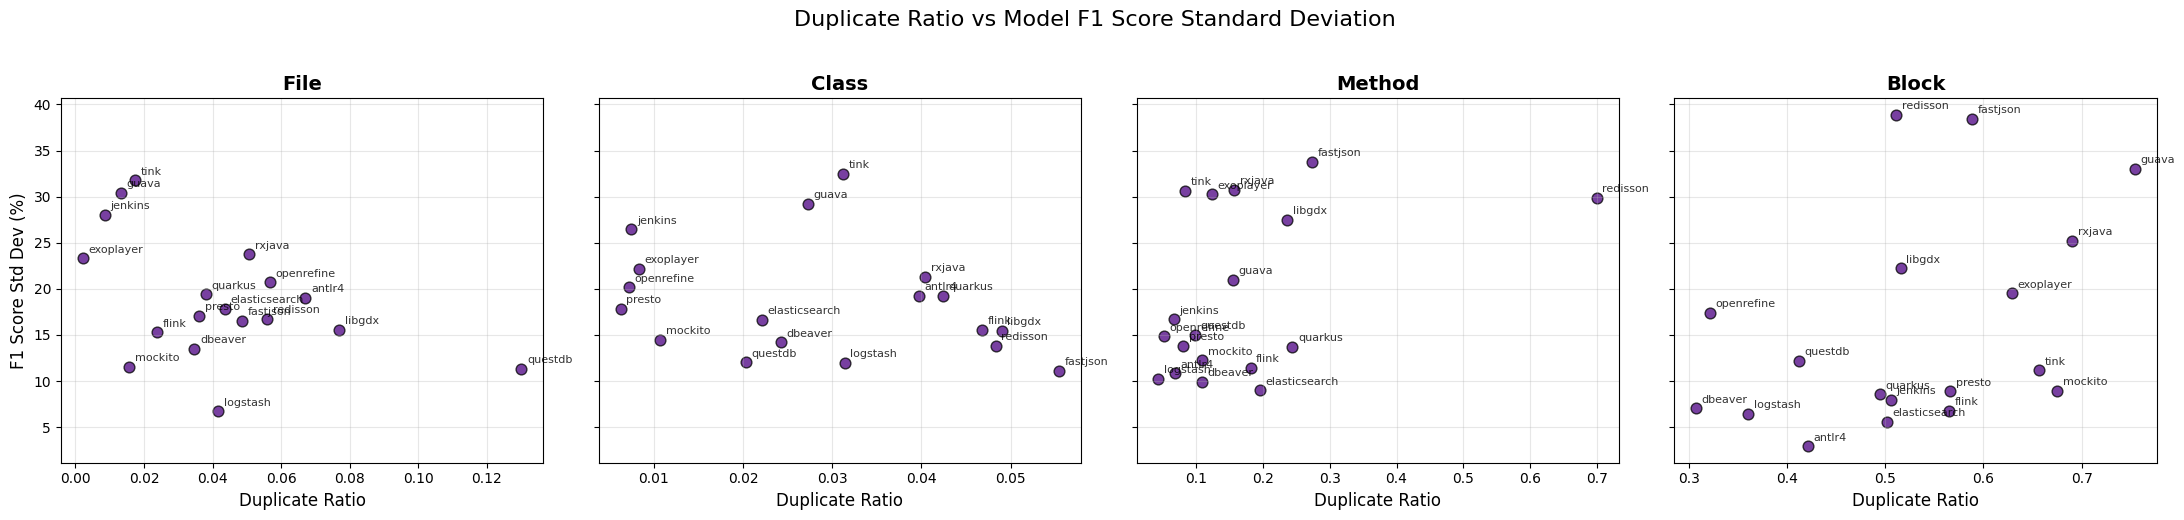

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Order of rows/columns
models = ["LightGBM", "LogisticRegression", "RF", "XGB"]
granularities = ["file", "class", "method", "block"]

# Function to convert LaTeX percentage strings to floats
def parse_percent(s):
    s = s.replace("\\enspace", "")
    s = s.replace("\\%", "")
    return float(re.sub(r"\s+", "", s))

# Create 1 row with 4 subplots (one per granularity)
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(granularities),
    figsize=(22, 5),
    sharey=True
)

for j, granularity in enumerate(granularities):
    ax = axes[j]

    counts_dict = dups_by_project[granularity]
    projects = list(counts_dict.keys())

    # Calculate duplicate ratio (or change to counts_dict[p]["duplicate_count"] if preferred)
    x = [counts_dict[p]["duplicate_count"] / counts_dict[p]["length"] for p in projects]

    # Calculate Standard Deviation of F1 score across all 4 models for each project
    y_std = []
    for p in projects:
        model_scores = [parse_percent(results_dict[model][granularity][p]) for model in models]
        y_std.append(np.std(model_scores, ddof=1))  # Sample standard deviation

    # Scatter plot
    ax.scatter(x, y_std, color="indigo", s=60, alpha=0.75, edgecolors="k")

    # Annotate points with project names
    for xx, yy, project in zip(x, y_std, projects):
        ax.annotate(
            project,
            (xx, yy),
            fontsize=8,
            alpha=0.8,
            xytext=(4, 4),
            textcoords="offset points"
        )

    ax.set_title(granularity.capitalize(), fontsize=14, fontweight="bold")
    ax.set_xlabel("Duplicate Ratio", fontsize=12)
    if j == 0:
        ax.set_ylabel("F1 Score Std Dev (%)", fontsize=12)

    ax.grid(True, alpha=0.3)

fig.suptitle("Duplicate Ratio vs Model F1 Score Standard Deviation", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()